In [10]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# change default font size to use for all plots labels and tick marks 
plt.rcParams.update({'font.size': 16})
# update theme to use for all plots
sns.set_theme(style="whitegrid", palette="pastel")

# path that contains .tsv files summarizing spliced vs unspliced read counts
mouse_paths = "/gpfs/commons/projects/knowles_singlecell_splicing/allen-brain/mouse_isocortex_hippocampal_2021/junctions"
human_paths = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/Leaflet"
mouse_cells = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/3_month'

# extract *.tsv files from each path and concatenate them into a single dataframe
# find all .tsv files in mouse_paths
mouse_files = !find $mouse_paths -name "*.tsv"
human_files = !find $human_paths -name "*.tsv"
mouse_cells = !find $mouse_cells -name "*.tsv"

# read all mouse files into a single dataframe and add column for species
mouse_df = pd.concat([pd.read_csv(f, sep='\t') for f in mouse_files])
mouse_df['species'] = 'mouse'
mouse_df['type'] = 'nuclei'

# read all human files into a single dataframe and add column for species
human_df = pd.concat([pd.read_csv(f, sep='\t') for f in human_files])
human_df['species'] = 'human'
human_df['type'] = 'nuclei'

mouse_cell_df = pd.concat([pd.read_csv(f, sep='\t') for f in mouse_cells])
mouse_cell_df['species'] = 'mouse'
mouse_cell_df['type'] = 'cells'

In [11]:
# concatenate mouse and human dataframes
df = pd.concat([mouse_df, human_df, mouse_cell_df])
df

,Sample,Total_Reads,Spliced_Reads,Unspliced_Reads,species,type
0,Aligned,6254896,678958,5575938,mouse,nuclei
0,Aligned,6261424,740860,5520564,mouse,nuclei
0,Aligned,6068138,590586,5477552,mouse,nuclei
0,Aligned,6447302,793979,5653323,mouse,nuclei
0,Aligned,6811170,653898,6157272,mouse,nuclei
...,...,...,...,...,...,...
0,Aligned,3191736,129766,3061970,human,nuclei
0,Aligned,2261218,66681,2194537,human,nuclei
0,CB,8062216,1735460,6326756,mouse,cells
0,CB,3261294,765805,2495489,mouse,cells


In [12]:
# add column for proportion of spliced reads 
df['proportion_spliced'] = df['Spliced_Reads'] / df['Total_Reads']
df['Splice_Reads_per_Million'] = df['Spliced_Reads'] / 1e6
df['Total_Reads_per_Million'] = df['Total_Reads'] / 1e6
df['Unspliced_Reads_per_Million'] = df['Unspliced_Reads'] / 1e6

In [13]:
df

,Sample,Total_Reads,Spliced_Reads,Unspliced_Reads,species,type,proportion_spliced,Splice_Reads_per_Million,Total_Reads_per_Million,Unspliced_Reads_per_Million
0,Aligned,6254896,678958,5575938,mouse,nuclei,0.108548,0.678958,6.254896,5.575938
0,Aligned,6261424,740860,5520564,mouse,nuclei,0.118321,0.740860,6.261424,5.520564
0,Aligned,6068138,590586,5477552,mouse,nuclei,0.097326,0.590586,6.068138,5.477552
0,Aligned,6447302,793979,5653323,mouse,nuclei,0.123149,0.793979,6.447302,5.653323
0,Aligned,6811170,653898,6157272,mouse,nuclei,0.096004,0.653898,6.811170,6.157272
...,...,...,...,...,...,...,...,...,...,...
0,Aligned,3191736,129766,3061970,human,nuclei,0.040657,0.129766,3.191736,3.061970
0,Aligned,2261218,66681,2194537,human,nuclei,0.029489,0.066681,2.261218,2.194537
0,CB,8062216,1735460,6326756,mouse,cells,0.215258,1.735460,8.062216,6.326756
0,CB,3261294,765805,2495489,mouse,cells,0.234816,0.765805,3.261294,2.495489


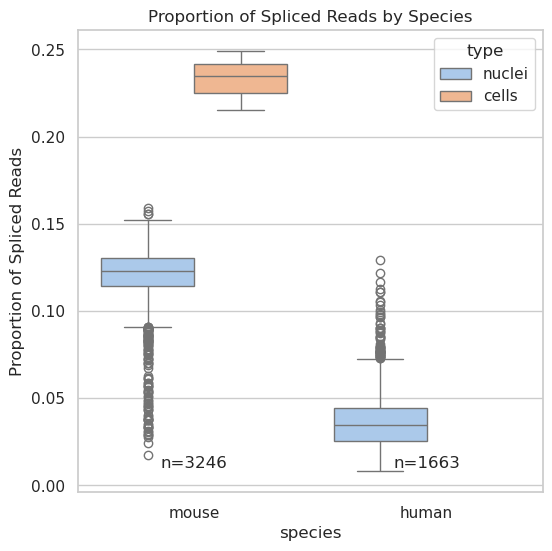

species  type  
human    nuclei    0.034731
mouse    cells     0.234816
         nuclei    0.122992
Name: proportion_spliced, dtype: float64

In [14]:
# plot boxlot of proportion of spliced reads for each species
plt.figure(figsize=(6, 6))
sns.boxplot(x='species', y='proportion_spliced', data=df, hue='type')
plt.ylabel('Proportion of Spliced Reads')
plt.title('Proportion of Spliced Reads by Species')

for i, species in enumerate(['mouse', 'human']):
    n = len(df[df['species'] == species])
    plt.text(i, 0.01, f'n={n}', ha='center')
plt.show()

# Summarize median proportion of spliced reads by species and type 
df.groupby(['species', 'type'])['proportion_spliced'].median()

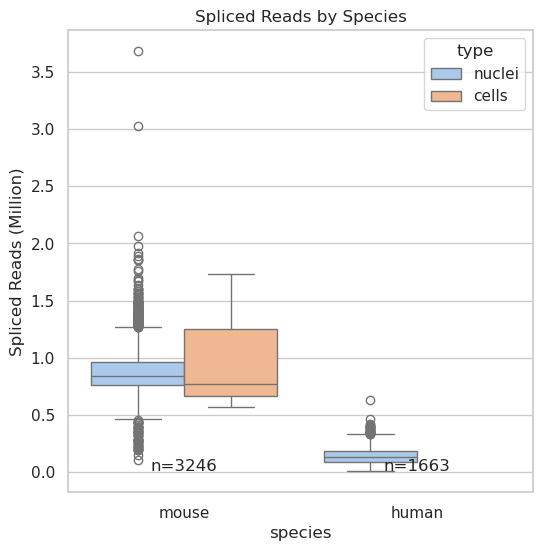

species  type  
human    nuclei    0.129143
mouse    cells     0.765805
         nuclei    0.840903
Name: Splice_Reads_per_Million, dtype: float64

In [15]:
# plot boxlot of proportion of spliced reads for each species
plt.figure(figsize=(6, 6))
sns.boxplot(x='species', y='Splice_Reads_per_Million', data=df, hue='type')
plt.ylabel('Spliced Reads (Million)')
plt.title('Spliced Reads by Species')

for i, species in enumerate(['mouse', 'human']):
    n = len(df[df['species'] == species])
    plt.text(i, 0.01, f'n={n}', ha='center')
plt.show()

df.groupby(['species', 'type'])['Splice_Reads_per_Million'].median()

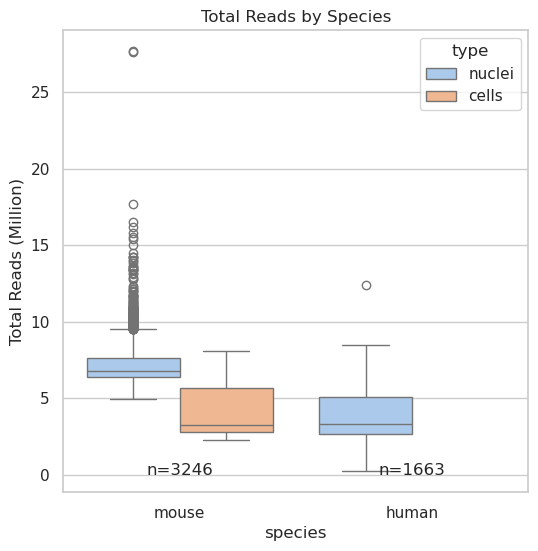

species  type  
human    nuclei    3.319186
mouse    cells     3.261294
         nuclei    6.789132
Name: Total_Reads_per_Million, dtype: float64

In [16]:
# plot boxlot of proportion of spliced reads for each species
plt.figure(figsize=(6, 6))
sns.boxplot(x='species', y='Total_Reads_per_Million', data=df, hue='type')
plt.ylabel('Total Reads (Million)')
plt.title('Total Reads by Species')

for i, species in enumerate(['mouse', 'human']):
    n = len(df[df['species'] == species])
    plt.text(i, 0.01, f'n={n}', ha='center')

# calculate median across specie and type 
medians = df.groupby(['species', 'type']).Total_Reads_per_Million.median().reset_index()

plt.show()
df.groupby(['species', 'type'])['Total_Reads_per_Million'].median()